In [ ]:
import sys
sys.path.append("../")

import os
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"

%reload_ext autoreload
%autoreload 2

In [ ]:
! pip install numpyro corner healpy einops reproject

In [ ]:
! sudo apt-get update
! sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
sys.path.append(r'/content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/')
%cd /content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks

Mounted at /content/drive
/content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks


In [ ]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
import arviz as az
import healpy as hp
#import mpltern
import corner
import pickle
import logging
from tqdm import tqdm
import json

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('matplotlibrc')

In [ ]:
jax.devices()

## 1. Simulation

In [ ]:
save_dir = "../outputs/poisson_sim/run_230718"

In [ ]:
from models.np_model import NPModel

In [ ]:
npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /content/drive/Othercomputers/My MacBook Pro/fermi-prob-prog/notebooks/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


### 1.1 Get reasonable data values

In [3]:
s = pickle.load(open('data/posteriors/np_sviiaf_par8_samples.p', 'rb'))

In [10]:
for k in s:
    if k.startswith('Alm') or k.startswith('n') or k.startswith('sb'):
        continue
    kshow = k.ljust(15)[:14]
    print(f'{kshow} : {np.median(s[k]):.3f}, {np.quantile(s[k], 0.18):.3f} - {np.quantile(s[k], 0.82):.3f}')

C              : 2.538, 2.015 - 3.195
S_bub          : 1.315, 1.232 - 1.396
S_dif          : 11.147, 10.992 - 11.279
S_gce          : 0.386, 0.288 - 0.516
S_ics          : 5.925, 5.775 - 6.086
S_iso          : 0.536, 0.423 - 0.680
S_psc          : 2.869, 1.558 - 3.996
Sps_dsk        : 1.015, 0.936 - 1.096
Sps_gce        : 1.086, 0.977 - 1.180
f_bulge_poiss  : 0.253, 0.173 - 0.357
f_bulge_ps     : 0.294, 0.216 - 0.387
gamma_poiss    : 0.924, 0.756 - 1.111
gamma_ps       : 1.211, 1.115 - 1.304
lambdas_dsk    : 0.414, 0.281 - 0.567
lambdas_gce    : 0.376, 0.254 - 0.518
theta_p_mcderm : 0.101, 0.015 - 0.452
theta_p_mcderm : 0.075, 0.010 - 0.357
theta_p_mcderm : 0.044, 0.009 - 0.160
theta_p_macias : 0.045, 0.000 - 0.483
theta_p_colema : 0.237, 0.008 - 0.659
theta_ps_mcder : 0.040, 0.008 - 0.176
theta_ps_mcder : 0.003, 0.000 - 0.068
theta_ps_mcder : 0.031, 0.006 - 0.135
theta_ps_macia : 0.611, 0.083 - 0.893
theta_ps_colem : 0.034, 0.000 - 0.572
theta_MO_ics   : 0.951, 0.883 - 0.980
theta_MA_

In [ ]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    S_dsk = 1.2, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 1.2, f_bulge_poiss = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
)
mu = npmodel.simulate_mu(var_dict)
#var_dict['mu'] = np.array(mu)
with open(f"{save_dir}/truth.json", 'w') as jf:
    save_dict = {}
    for k, item in var_dict.items():
        if isinstance(item, np.ndarray):
            save_dict[k] = item.tolist()
        else:
            save_dict[k] = item
    json.dump(save_dict, jf)
np.save(f"{save_dir}/mu.npy", mu)

In [ ]:
rng_key = jax.random.PRNGKey(42)

for i in tqdm(range(100)):
    rng_key, key = jax.random.split(rng_key)
    counts = jax.random.poisson(key, mu)
    np.save(f"{save_dir}/counts_{i}.npy", np.array(counts, dtype=np.int32))

100%|██████████| 100/100 [00:01<00:00, 70.69it/s]


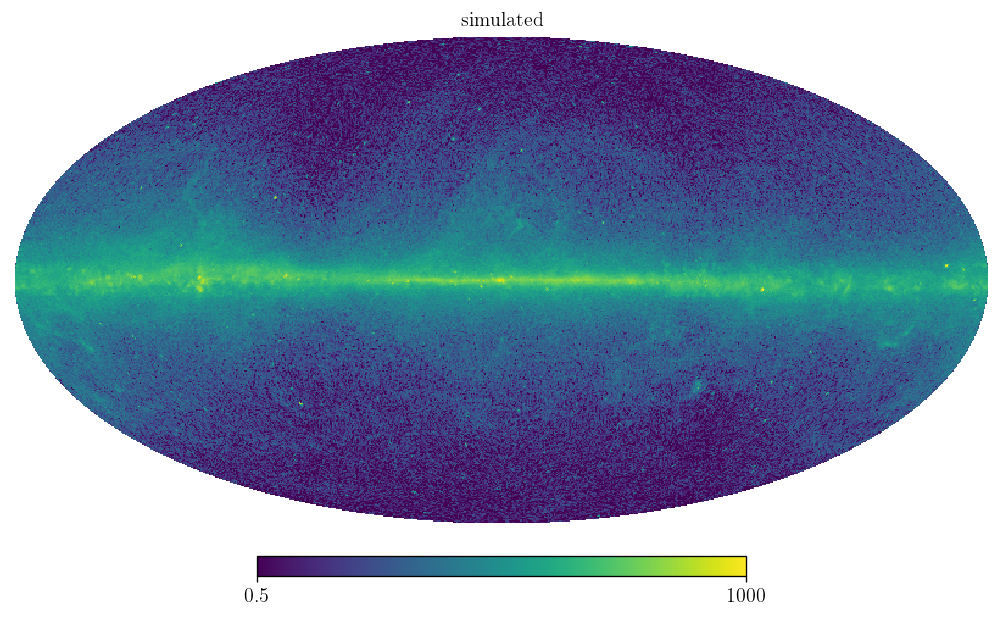

In [ ]:
hp.mollview(jnp.clip(counts, 0.5, None), norm='log', max=1000, title='simulated')
plt.show()

## 2. Fit

### 2.1 SVI

In [ ]:
for i in range(74,80):
    counts = jnp.array(np.load(f"{save_dir}/counts_{i}.npy"), dtype=jnp.int32)
    svi_results = npmodel.fit_svi(
        rng_key=jax.random.PRNGKey(4234),
        n_steps=2000,
        guide="iaf",
        lr=5e-5,
        num_particles=8,
        data=jnp.array(counts),
    )
    pickle.dump(svi_results, open(f"{save_dir}/svi_results_{i}.p", 'wb'))
    samples = npmodel.get_svi_samples(
        rng_key=jax.random.PRNGKey(42),
        num_samples=50000,
    )
    pickle.dump(samples, open(f"{save_dir}/samples_{i}.p", 'wb'))

In [ ]:
plt.plot(svi_results.losses)
plt.loglog()

## 3. View

In [ ]:
from utils.multi_corner import multi_corner

In [ ]:
samples = pickle.load(open('../outputs/poisson_sim/test_samples.p', 'rb'))

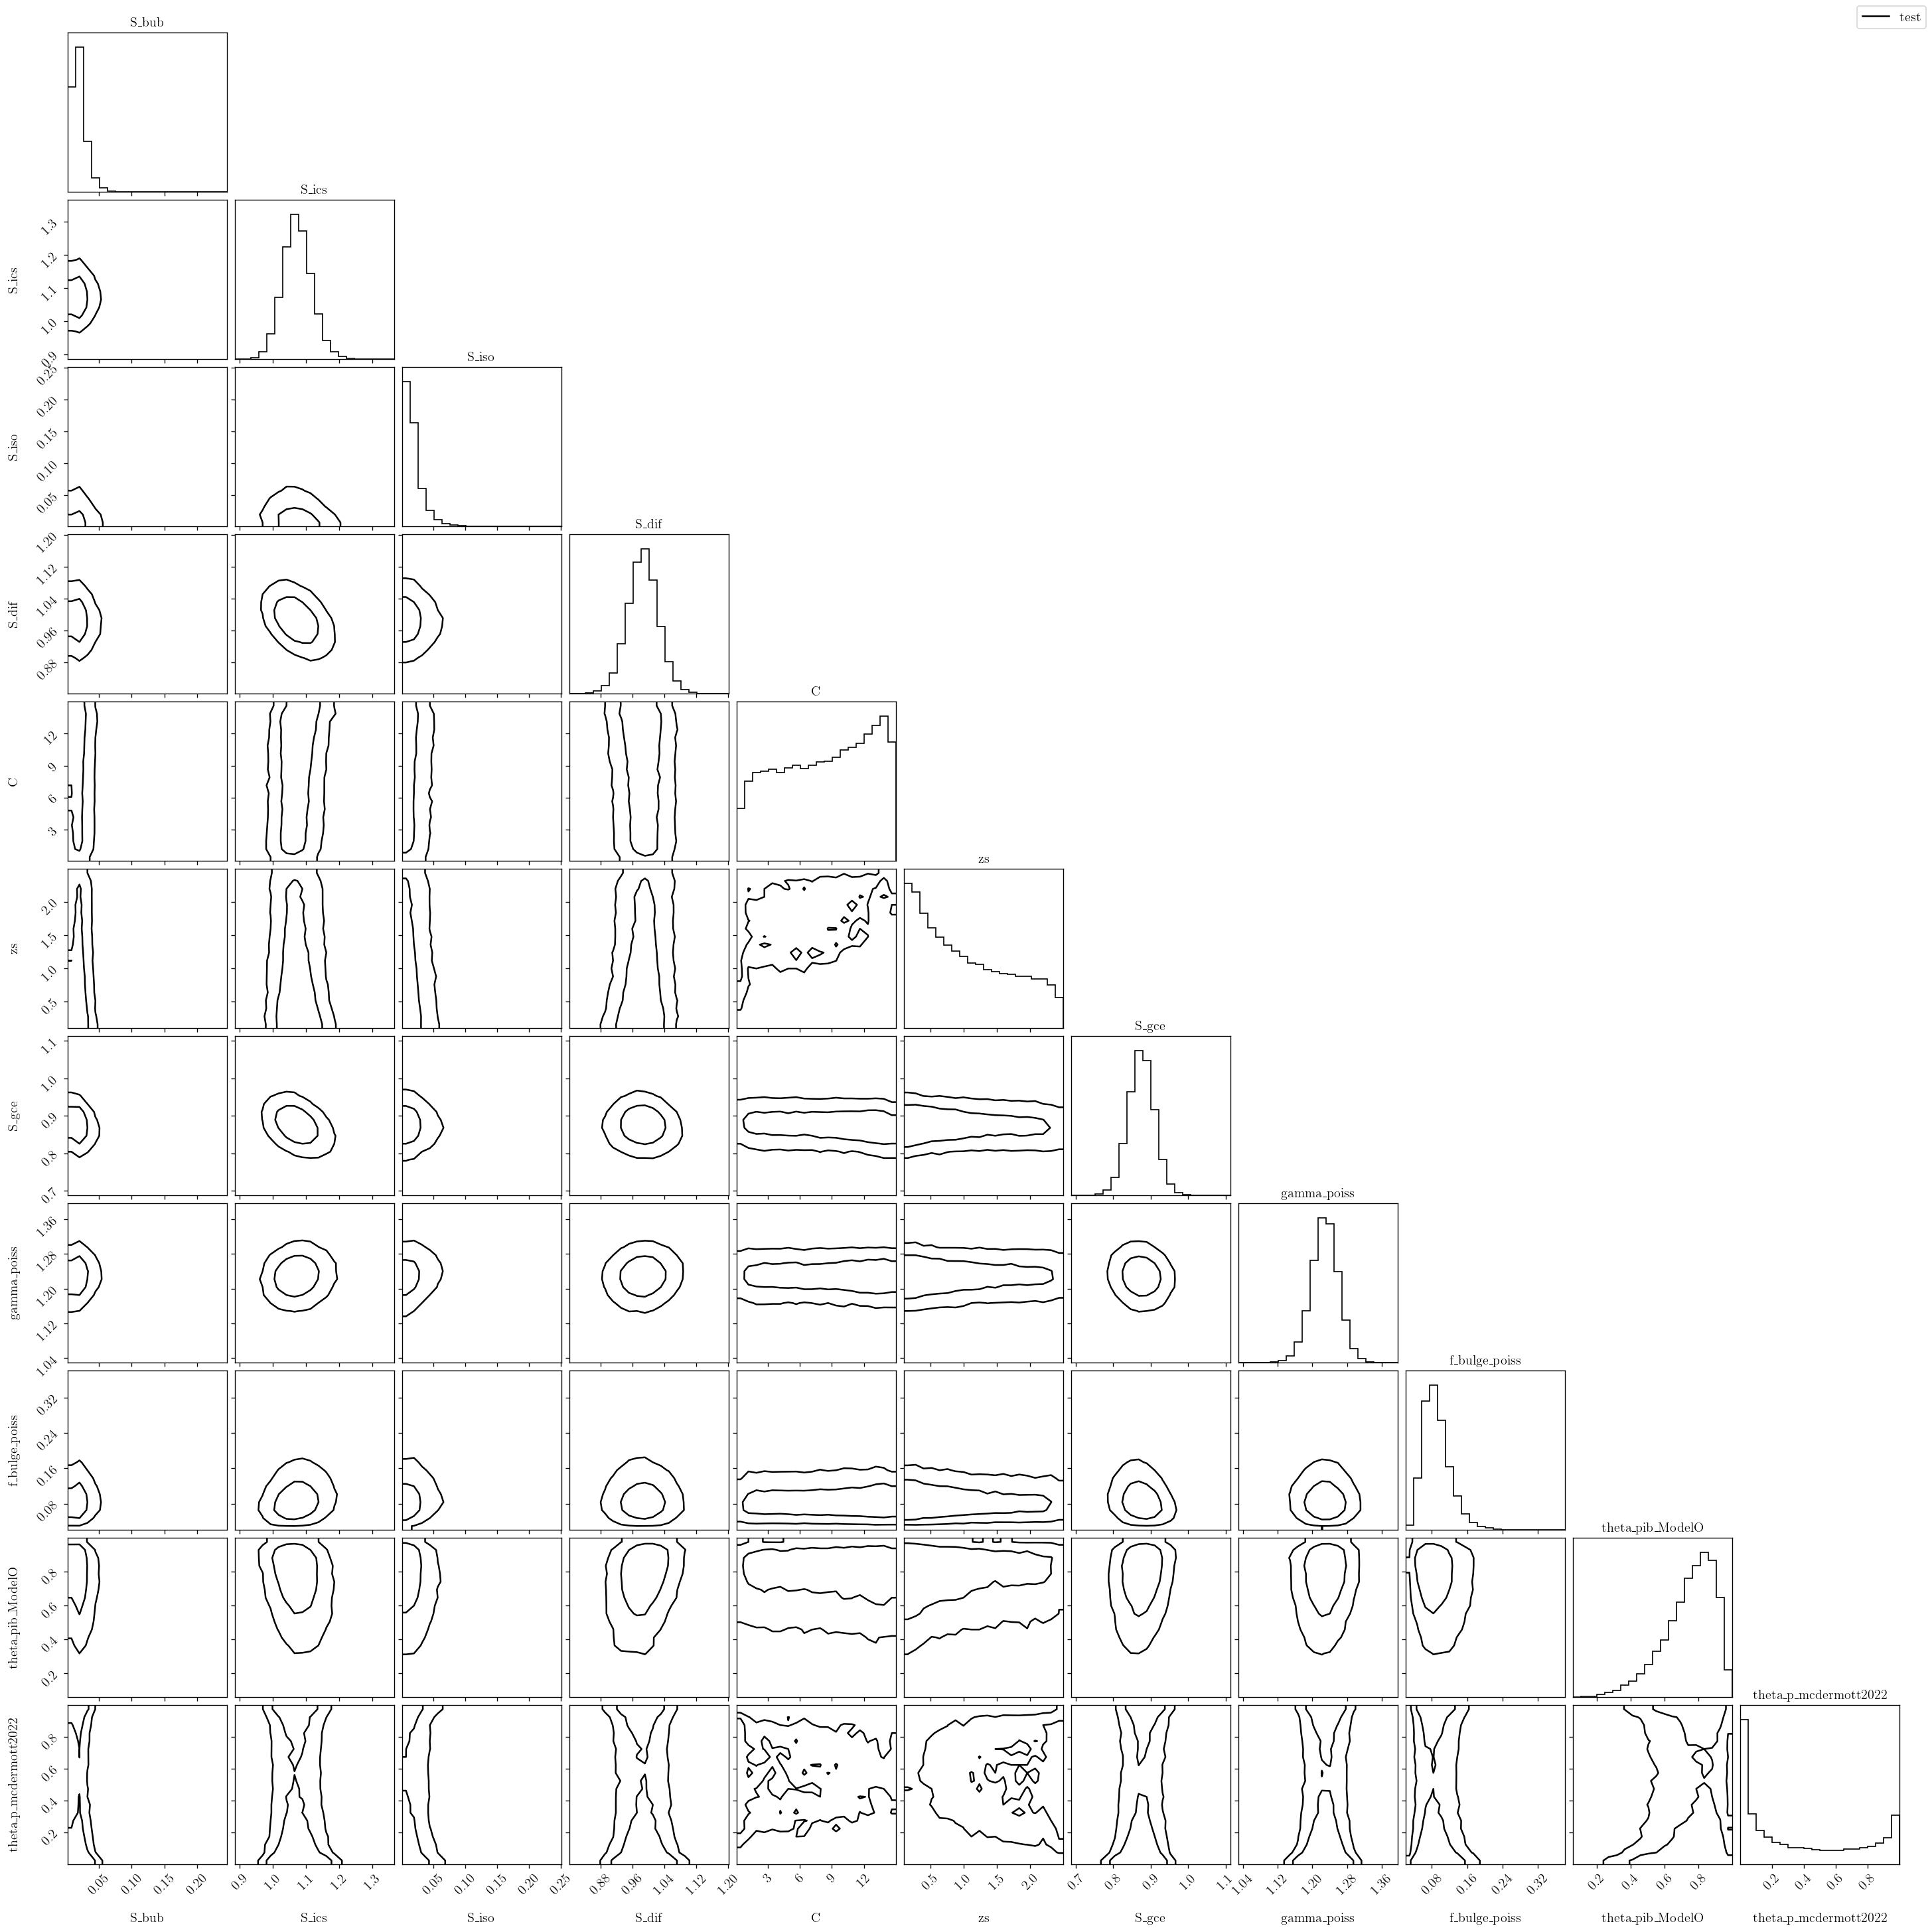

In [ ]:
samples_dict = {
    '' : samples
}
colors_dict = {
    '' : 'k'
}
labels_dict = {
    '' : 'test'
}
plot_var_names = [
    'S_bub', 'S_ics', 'S_iso', 'S_dif',
    'C', 'zs',
    'S_gce', 'gamma_poiss', 'f_bulge_poiss',
    'theta_pib_ModelO', 'theta_p_mcdermott2022'
]

logging.getLogger().setLevel(logging.ERROR)
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1, save_fn='../outputs/test.pdf'
)